In V6, we will do a direct comparison between the following models: Random Forest, XGBoost, Ridge Regression, and Gaussian Process Regression. We already tuned our RF Model in V5, and we will employ the exact same tuning process to the other 3 candidates, determine what the best candidate is in terms of cross validatibility and split testing R^2 values. XGBoost, Ridge Regression, and Gaussian Process Regression (GPR) were selected as candidates because each is better suited to small dataset regimes than random forest: XGBoost through sequential error correction, Ridge Regression through regularized linear fitting, and GPR through probabilistic interpolation.

In [1]:
from mp_api.client import MPRester
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
load_dotenv()
MY_API_KEY = os.getenv("MP_API_KEY")

In [2]:
# Import helper functions and global vars from utils
from utils import query_materials_project, ionic_radii, compute_tolerance_factor, halides, metals

In [3]:
halide_families = [[metal, halide] for metal in metals for halide in halides]

# Query and save with date stamp when refreshing the dataset
# df = query_materials_project(MY_API_KEY, halide_families)
# After querying, save once:
# df.to_csv("../data/perovskite_dataset.csv_PLACEHOLDER_DATE", index=False)
df = pd.read_csv("../data/perovskite_dataset_6_12_2026.csv")

print(f"Found {len(df)} materials after cleaning")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())

Found 305 materials after cleaning
       formula  band_gap  energy_above_hull  formation_energy       volume  \
0        SnBrF    1.9941           0.231295         -1.642101   133.175737   
1  SnHg2(SBr)2    2.1758           0.132910         -0.584547  1406.327307   
2  SnHg2(SBr)2    2.3372           0.051968         -0.665489  1225.587703   
3  SnHg2(SBr)2    2.3254           0.071865         -0.645593  1283.062309   
4  SnHg2(SBr)2    1.9584           0.005744         -0.711713   851.167057   

    density  nsites  spacegroup_number  
0  5.426723       6                129  
1  3.513138      28                 14  
2  4.031227      28                 14  
3  3.850648      28                 14  
4  5.804527      28                 14  

Missing values per column:
formula              0
band_gap             0
energy_above_hull    0
formation_energy     0
volume               0
density              0
nsites               0
spacegroup_number    0
dtype: int64


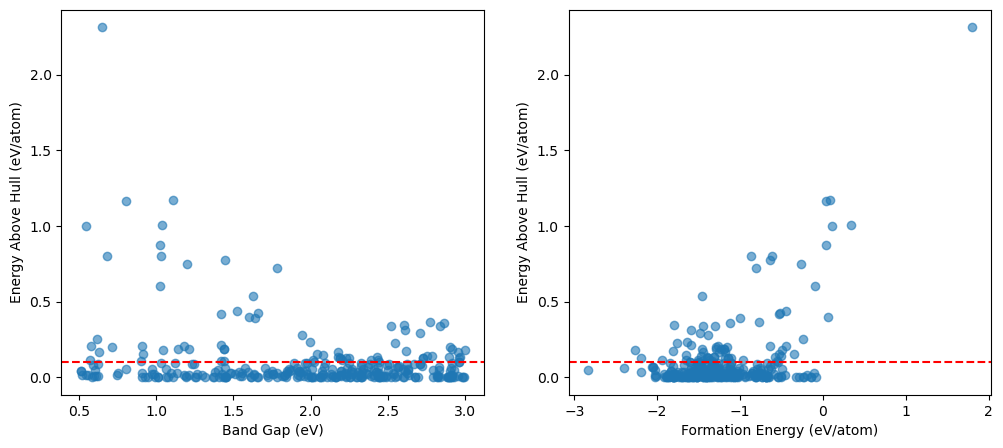

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Plotting Band Gap vs Stability (energy above hull)
axes[0].scatter(df["band_gap"], df["energy_above_hull"], alpha = 0.6)
axes[0].axhline(y = 0.1, color = "r", linestyle = "--")
axes[0].set_xlabel("Band Gap (eV)")
axes[0].set_ylabel("Energy Above Hull (eV/atom)")

# Plotting Formation energy vs. Stability (energy above hull)
axes[1].scatter(df["formation_energy"], df["energy_above_hull"], alpha= 0.6)
axes[1].axhline(y = 0.1, color = "r", linestyle = "--")
axes[1].set_xlabel("Formation Energy (eV/atom)")
axes[1].set_ylabel("Energy Above Hull (eV/atom)")

plt.show()

In [5]:
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

str_to_comp = StrToComposition()
df = str_to_comp.featurize_dataframe(df, "formula", ignore_errors=True)
ep_featurizer = ElementProperty.from_preset("magpie")
df = ep_featurizer.featurize_dataframe(df, col_id = "composition", ignore_errors=True)

StrToComposition:   0%|          | 0/305 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/305 [00:00<?, ?it/s]

MODEL 1: XGBOOST

WHY THIS MODEL:

XGBoost works still by using decision trees. However, instead of training them in parallell, the model does sequential triaining to account for the errors accrued by each individual tree. It is, in theory, suited to small datasets because it focuses learning effort on hard-to-predict samples rather than treating all samples equally. The regularization parameters (learning rate, subsample) control overfitting explicitly. Because RF notably struggles with small dataset size, XGBoost is the most logical next candidate. 

In [6]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Cleaning non-numeric features from the dataframe as the model cannot use them
exclude_cols = ["formula", "composition", "energy_above_hull", "band_gap",
"formation_energy", "volume", "density", "nsites"]
feature_cols = [col for col in df.columns if col not in exclude_cols]
df_clean = df.dropna(subset = feature_cols  + ["energy_above_hull"])
X = df_clean[feature_cols]
y = df_clean["energy_above_hull"]
print(f"Post cleaning and featurization, we are now training on {X.shape[0]} materials with {X.shape[1]} features")

Post cleaning and featurization, we are now training on 305 materials with 133 features


In [7]:
# Cross validate XGBoost with default hyperparameters
kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb = XGBRegressor(n_estimators=200, random_state=42, n_jobs=-1)
scores_xgb = cross_val_score(xgb, X, y, cv=kf, scoring="r2")
 
print(f"XGBoost CV R² scores: {scores_xgb}")
print(f"Mean R²: {scores_xgb.mean():.4f}")
print(f"Std R²: {scores_xgb.std():.4f}")

XGBoost CV R² scores: [0.53610253 0.52671254 0.66231702 0.71197123 0.22492865]
Mean R²: 0.5324
Std R²: 0.1695


As we can see, we already have a slight improvement in our R^2 value and the standard deviaiton of the R^2s from our cross validation step. The optimized random forest regressor model from V5 had a mean R^2 of 0.55 with a std deviation of 0.18. Our untuned XGBoost model has a higher mean R^2 at 0.59 with a comparable std deviation. Following the same process as V5, we will use RandomizedSearchCV to find the best hyperparameters to maximize the mean R^2 of our cross validated set. 

In [8]:
# Tune XGBoost hyperparameters with RandomizedSearchCV
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

# Find the best hyperparameters using RandomizedSearchCV with 5-fold cross-validation
search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_dist,
    n_iter=30,
    cv=kf,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)
search.fit(X, y)
print(f"Best parameters: {search.best_params_}")
print(f"Best CV R²: {search.best_score_:.4f}")

Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV R²: 0.6580


In [9]:
# Retrain XGBoost with the best hyperparameters and evaluate on a test set
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y, test_size=0.2, random_state=42)
best_xgb = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1)
scores_tuned = cross_val_score(best_xgb, X, y, cv=kf, scoring="r2")

print(f"CV R² scores: {scores_tuned}")
print(f"Mean R²: {scores_tuned.mean():.4f}")
print(f"Std R²: {scores_tuned.std():.4f}")

CV R² scores: [0.77290479 0.47919243 0.71280771 0.78973161 0.46517045]
Mean R²: 0.6440
Std R²: 0.1426


In [10]:

# Display number of samples in training and testing sets
print(f"Training set: {X_train_xgb.shape[0]} samples")
print(f"Testing set: {X_test_xgb.shape[0]} samples")

xgb = XGBRegressor(**search.best_params_, random_state=42, n_jobs=-1)
xgb.fit(X_train_xgb, y_train_xgb   )

# Evaluate
# Using the trained model, we take our testing data, X_test, and predict the energy above hull values, y_pred
# We then compare these predicted values against the actual test values, y_test, and claculate r^2 values and mean absolute error.
y_pred_xgb = xgb.predict(X_test_xgb)
mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)
r2 = r2_score(y_test_xgb, y_pred_xgb)

# Finally, we print out our evaluation of the model's accuracy 
print(f"Mean Absolute Error: {mae_xgb:.4f} eV/atom")
print(f"R² Score: {r2:.4f}")
print(f"R² Score (Training): {r2_score(y_train_xgb, xgb.predict(X_train_xgb)):.4f}")

Training set: 244 samples
Testing set: 61 samples
Mean Absolute Error: 0.0598 eV/atom
R² Score: 0.6827
R² Score (Training): 0.9992


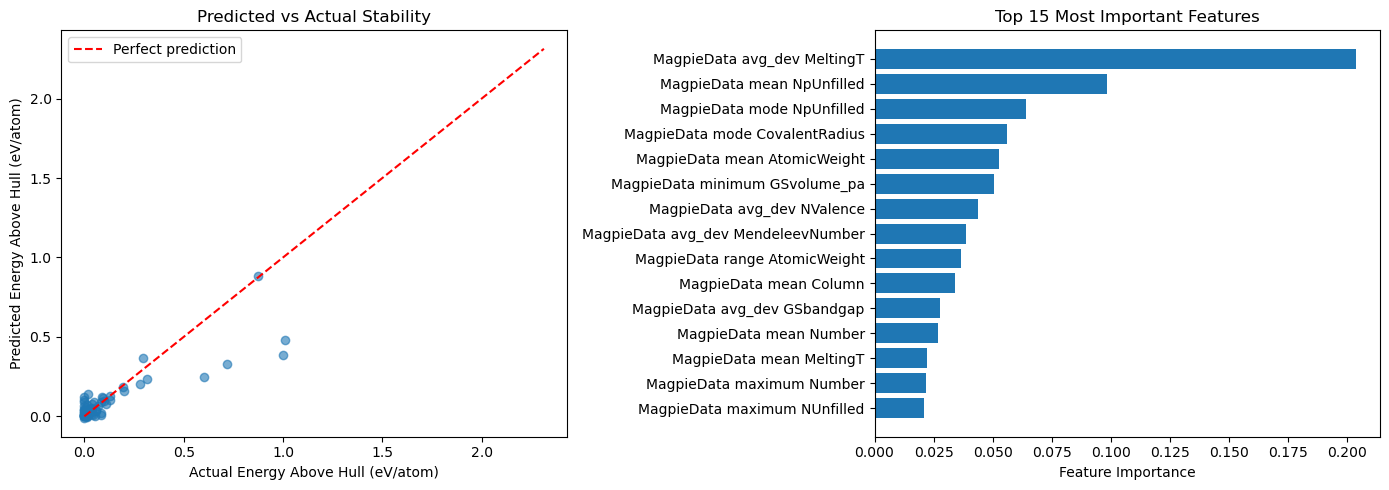

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test_xgb, y_pred_xgb, alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel("Actual Energy Above Hull (eV/atom)")
axes[0].set_ylabel("Predicted Energy Above Hull (eV/atom)")
axes[0].set_title("Predicted vs Actual Stability")
axes[0].legend()

# Top 15 most important features
importances = pd.Series(xgb.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)
axes[1].barh(top_features.index[::-1], top_features.values[::-1])
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 15 Most Important Features")

plt.tight_layout()
plt.show()

Comparing results to our tuned Random Forest Model, XGBoost provides a marked improvement in peroformance. Comparing cross validation scores, we have a mean 0.64 R^2 and 0.13 standard deviation for XGBoost compared to RF's 0.55 R^2 with a 0.18 standard deviation. In both realms of R^2 value and standard deviation, XGBoost is superior. Comparing our final R^2 values when running the train test split, we get a test R^2 of 0.64 and a train R^2 of 0.99 for XGBoost. For the Random Forest model we had a test R^2 of 0.47 and a train R^2 of 0.93. Notably, XGBoost's apparent memorization of training data is more pronounced than in the RF Model. However, the gap between the train and test R^2 values in XGBoost is smaller than the gap in these metrics for RF. Because we are focused on this gap and the test R^2 value explicitly, and XGBoost performs better for both of these values, XGBoost seems to be a more appropriate model candidate. 

MODEL 2: RIDGE REGRESSION

WHY THIS MODEL:

Ridge Regression works by equating hull energy to a weighted sum of the individual feature values. We ahve an explicit parameter, alpha, that provides a penalty to prevent overfitting. We want to simultaneously see if there is a linear relationship between the features and our hull energy value, and address our overfitting problem. In particular, if we observe comparable or improved performance between XGBoost and Ridge, then that implies that the relationship between hull energy and feature values is approximately linear. In other words, the feature impacts are linearly independent. 

In [12]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Ridge requires feature scaling since it penalizes large coefficients
# We wrap it in a Pipeline with StandardScaler to handle this automatically
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

# we tune the alpha penalty parameter for Ridge regression using RandomizedSearchCV
param_dist_ridge = {
    "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_dist_ridge,
    n_iter=6,
    cv=kf,
    scoring="r2",
    random_state=42
)
ridge_search.fit(X, y)
print(f"Best alpha: {ridge_search.best_params_}")
print(f"Best CV R²: {ridge_search.best_score_:.4f}")

scores_ridge = cross_val_score(ridge_search.best_estimator_, X, y, cv=kf, scoring="r2")
print(f"CV R² scores: {scores_ridge}")
print(f"Mean R²: {scores_ridge.mean():.4f}")
print(f"Std R²: {scores_ridge.std():.4f}")

Best alpha: {'ridge__alpha': 10.0}
Best CV R²: 0.3542
CV R² scores: [0.5744061  0.26591267 0.27926573 0.5392158  0.11226956]
Mean R²: 0.3542
Std R²: 0.1759


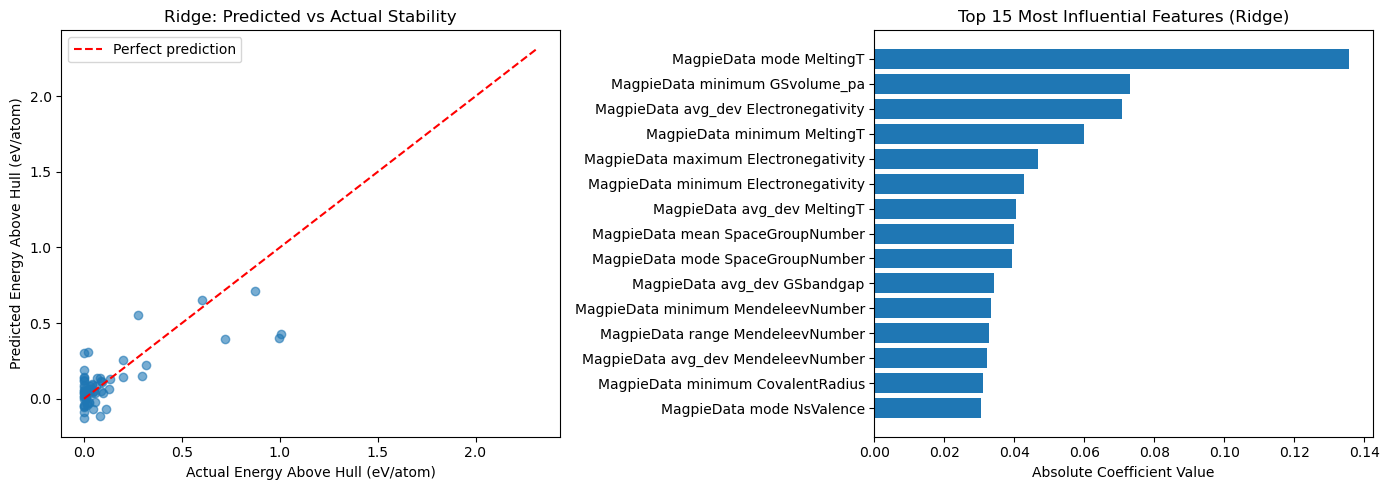

Mean Absolute Error: 0.0954 eV/atom
R² Score: 0.5744
R² Score (Training): 0.7768


In [13]:
X_train_ridge, X_test_ridge, y_train_ridge, y_test_ridge = train_test_split(X, y, test_size=0.2, random_state=42)

best_ridge = ridge_search.best_estimator_
best_ridge.fit(X_train_ridge, y_train_ridge)
y_pred_ridge = best_ridge.predict(X_test_ridge)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test_ridge, y_pred_ridge, alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel("Actual Energy Above Hull (eV/atom)")
axes[0].set_ylabel("Predicted Energy Above Hull (eV/atom)")
axes[0].set_title("Ridge: Predicted vs Actual Stability")
axes[0].legend()

# Feature coefficients (we will use this to rank the most impactful features)
coefficients = pd.Series(
    best_ridge.named_steps["ridge"].coef_,
    index=feature_cols
)
top_coefficients = coefficients.abs().sort_values(ascending=False).head(15)
axes[1].barh(top_coefficients.index[::-1], top_coefficients.values[::-1])
axes[1].set_xlabel("Absolute Coefficient Value")
axes[1].set_title("Top 15 Most Influential Features (Ridge)")

plt.tight_layout()
plt.show()

print(f"Mean Absolute Error: {mean_absolute_error(y_test_ridge, y_pred_ridge):.4f} eV/atom")
print(f"R² Score: {r2_score(y_test_ridge, y_pred_ridge):.4f}")
print(f"R² Score (Training): {r2_score(y_train_ridge, best_ridge.predict(X_train_ridge)):.4f}")

Comparing our results between our current best candidate, XGBoost and Ridge Regression, we observe that XGBoost performs better. In terms of cross-validation, we observe a mean R^2 of 0.4 with a standard deviation of 0.13 for Ridge Regression compared with XGBoost's mean R^2 of 0.64 with a standard deviation of 0.13 as well.

In terms of run performance with optimized hyperparameters we observe Ridge Regression having a test R^2 of 0.55 and a train R^2 of 0.79. On the other hand, XGBoost, has a test R^2 of 0.64 and a train R^2 of 0.99. Ridge Regression appears to perform better against overfitting, but the predictive power of the XGBoost model is still superior. 

We also mentioned at the start of the Ridge Regression Testing that we wanted to see how a linear model would perform on this data. This test confirms that features interact and a linear combination of them cannot accurately represent the complexity of this dataset.

MODEL 3: Gaussian Process Regression

WHY THIS MODEL:

So far, our models have been rather prone to overfitting. GPR addresses this by maintaining a probability distribution over all functions consistent with the training data, rather than committing to a single function. Predictions are made by averaging over this distribution, weighted by a kernel function (a matrix with values between 0,1 that encodes similarity values between different structures based on features). This algorithm produces both a predicted value and an uncertainty estimate, this latter part being a unique output that helps us classify its efficacy. 

In [14]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

gpr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(
        kernel=RBF() + WhiteKernel(),
        random_state=42,
        n_restarts_optimizer=5
    ))
])

# Fit and cross validate
scores_gpr = cross_val_score(gpr_pipeline, X, y, cv=kf, scoring="r2")
print(f"GPR CV R² scores: {scores_gpr}")
print(f"Mean R²: {scores_gpr.mean():.4f}")
print(f"Std R²: {scores_gpr.std():.4f}")

GPR CV R² scores: [0.13855379 0.12758083 0.33538586 0.26850939 0.29019408]
Mean R²: 0.2320
Std R²: 0.0837


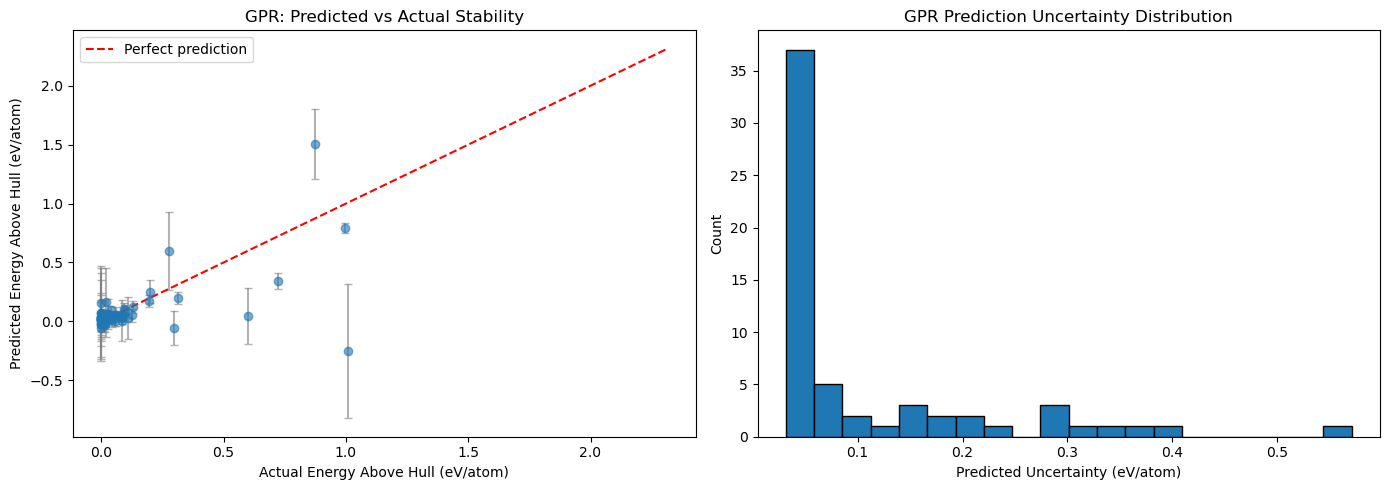

Mean Absolute Error: 0.0927 eV/atom
R² Score: 0.1386
R² Score (Training): 0.9952
Mean prediction uncertainty: 0.1078 eV/atom


In [15]:
X_train_gpr, X_test_gpr, y_train_gpr, y_test_gpr = train_test_split(X, y, test_size=0.2, random_state=42)

gpr_pipeline.fit(X_train_gpr, y_train_gpr)

# GPR returns both predictions and uncertainty estimates
y_pred_gpr, y_std_gpr = gpr_pipeline.named_steps["gpr"].predict(
    gpr_pipeline.named_steps["scaler"].transform(X_test_gpr), 
    return_std=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual with uncertainty bars
axes[0].errorbar(y_test_gpr, y_pred_gpr, yerr=y_std_gpr, 
                 fmt='o', alpha=0.6, ecolor='gray', capsize=3)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel("Actual Energy Above Hull (eV/atom)")
axes[0].set_ylabel("Predicted Energy Above Hull (eV/atom)")
axes[0].set_title("GPR: Predicted vs Actual Stability")
axes[0].legend()

# Uncertainty distribution
axes[1].hist(y_std_gpr, bins=20, edgecolor='black')
axes[1].set_xlabel("Predicted Uncertainty (eV/atom)")
axes[1].set_ylabel("Count")
axes[1].set_title("GPR Prediction Uncertainty Distribution")

plt.tight_layout()
plt.show()

print(f"Mean Absolute Error: {mean_absolute_error(y_test_gpr, y_pred_gpr):.4f} eV/atom")
print(f"R² Score: {r2_score(y_test_gpr, y_pred_gpr):.4f}")
print(f"R² Score (Training): {r2_score(y_train_gpr, gpr_pipeline.predict(X_train_gpr)):.4f}")
print(f"Mean prediction uncertainty: {y_std_gpr.mean():.4f} eV/atom")

Based on both training and testing R^2 in addition to cross validation, GPR appears to be the least effective candidate. the training R^2 is 0.99 whereas the test R^2 is at -0.05. For its cross validation score, it has a mean R^2 of 0.21 with a standard deviation of 0.2.

As for why GPR likely failed, we turn to the explanatory power of the negative R^2 value. Because our dataset size is so small, the Kernel matrix, which encodes similarity values between different samples, encountered many adjacent samples with little to no similarity. This resulted in a collapse in the similarity scores of the matrix to 0, meaning our kernel matrix visually approaches the identity matrix. This means that our test points are weighted almost none by the training datapoints because they are so dissimilar from eachother. Because the model starts of with the assumed output of 0, its prediction value will also be very close to 0. The mean of the data is slightly greater than zero which then is why our R^2 is negative.

In [16]:
# Results with spacegroup number included as a feature
results_with_spacegroup = {
    "Model": ["Random Forest (tuned)", "XGBoost (tuned)", "Ridge", "GPR"],
    "CV Mean R²": [0.50, 0.64, 0.35, 0.23],
    "CV Std R²": [0.17, 0.14, 0.18, 0.08],
    "Test R²": [0.59, 0.68, 0.57, 0.14],
}
summary_df = pd.DataFrame(results_with_spacegroup)
print(summary_df.to_string(index=False))

                Model  CV Mean R²  CV Std R²  Test R²
Random Forest (tuned)        0.50       0.17     0.59
      XGBoost (tuned)        0.64       0.14     0.68
                Ridge        0.35       0.18     0.57
                  GPR        0.23       0.08     0.14


In [ ]:
# Excluded spacegroup number results (to test, simply add spacegroup number in the exclude cols function earlier int he notebook)
results_without_spacegroup = {
    "Model": ["Random Forest (tuned)", "XGBoost (tuned)", "Ridge", "GPR"],
    "CV Mean R²": [0.49, 0.61, 0.36, 0.22],
    "CV Std R²": [0.20, 0.13, 0.18, 0.09],
    "Test R²": [0.55, 0.71, 0.60, 0.13],
}
summary_df = pd.DataFrame(results_without_spacegroup)
print(summary_df.to_string(index=False))

                Model  CV Mean R²  CV Std R²  Test R²
Random Forest (tuned)        0.49       0.20     0.55
      XGBoost (tuned)        0.61       0.13     0.71
                Ridge        0.36       0.18     0.60
                  GPR        0.22       0.09     0.13


Having tested the following models: Random Forest, Boosted Trees (XGBoost), Ridge Regression, and Gaussian Process Regression — we determined that the best candidate, both in terms of predictive power (highest test R²) and cross-validation variance, was the boosted trees model (see the tables above). Moving forward, given our small dataset size, we will opt for XGBoost over the Random Forest model.

Lastly, we tested how removing the spacegroup number changed the output R² values for each model. We initially overlooked the fact that spacegroup number is a structural property: it describes the crystallographic form of a specific perovskite polymorph. The only input we provide to the model at prediction time is the chemical formula. Because we intend to use this model on uncharacterized, theoretical compositions (for which the structure and therefore spacegroup are unknown), and which may have several polymorphs each with a different spacegroup, we cannot rely on spacegroup number as a training feature. That value simply would not be available for the candidates we want to screen.

Both tables above were generated using the same pipeline, toggling only the spacegroup_number feature in or out, with all other steps held constant. Comparing them, the changes are minor: for XGBoost, cross-validated R² drops slightly (0.64 → 0.61) while test R² actually improves slightly (0.68 → 0.71), and the other models move negligibly. This is consistent with spacegroup_number being unhelpful for our chosen model, so removing it costs us nothing in performance while making the model valid for its intended use case.

This is reinforced by the feature analysis earlier in the notebook: for the two models where we examined feature importance (XGBoost) and coefficients (Ridge), the structural spacegroup_number does not appear in the top 15. Notably, the MAGPIE SpaceGroupNumber statistics (minimum, mean, etc.) rank highly. It is worth being precise about what these are: they are computed from the standard reference structures of the constituent elements, not from the compound's actual crystal structure, and they are fully calculable from the formula alone. They are therefore a separate, composition-based signal rather than a replacement for the structural spacegroup we removed. 